In [1]:
import tensorflow as tf
from tensorflow.keras.applications import NASNetLarge
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os
from tensorflow.keras.layers import Flatten, Dense

In [2]:
# Paths to data
train_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Train'
val_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Validation'
img_size = 224  # Standard input size for DenseNet201
batch_size = 32
seed = 123

# =====================================================================
#                     Simplified Dataset Loading
# =====================================================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True
)


# Optimize data loading
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 4540 files belonging to 4 classes.
Found 456 files belonging to 4 classes.


In [3]:
# Load base model (without top layer)
base_model = NASNetLarge(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

for layer in base_model.layers:
    layer.trainable = False 

# Add custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(1024, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

343610240/343610240 ━━━━━━━━━━━━━━━━━━━━ 248s 1us/step


In [4]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv1 (Conv2D)           │ (None, 111, 111, 96)      │           2,592 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn1 (BatchNormalization) │ (None, 111, 111, 96)      │             384 │ stem_conv1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 111, 111, 96)      │               0 │ stem_bn1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reduction_conv_1_stem_1       │ (None, 111, 111, 42)      │           4,032 │ activation[0][0]           │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reduction_bn_1_stem_1         │ (None, 111, 111, 42)      │             168 │ reduction_conv_1_stem_1[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 111, 111, 42)      │               0 │ reduction_bn_1_stem_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_3 (Activation)     │ (None, 111, 111, 96)      │               0 │ stem_bn1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv_1_pad_reducti… │ (None, 115, 115, 42)      │               0 │ activation_1[0][0]         │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv_1_pad_reducti… │ (None, 117, 117, 96)      │               0 │ activation_3[0][0]         │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv_1_reduction_l… │ (None, 56, 56, 42)        │           2,814 │ separable_conv_1_pad_redu… │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv_1_reduction_r… │ (None, 56, 56, 42)        │           8,736 │ separable_conv_1_pad_redu… │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv_1_bn_reductio… │ (None, 56, 56, 42)        │             168 │ separable_conv_1_reductio… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ separable_conv_1_bn_reductio… │ (None, 56, 56, 42)        │             16

 Total params: 89,050,710 (339.70 MB)

 Trainable params: 4,133,892 (15.77 MB)

 Non-trainable params: 84,916,818 (323.93 MB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint

# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=5,              # Wait for 3 epochs with no improvement
    restore_best_weights=True  # Restore model weights from the best epoch
)
checkpoint = ModelCheckpoint(
    'best_model.keras',          # File to save
    monitor='val_accuracy',    # Metric to watch
    save_best_only=True,       # Only save best model
    mode='max',                # 'max' for accuracy, 'min' for loss
    verbose=1                  # Print when saved
)

In [6]:
model.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False), 
    metrics=['accuracy']
)
# Initial training with frozen base
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    shuffle = False
)

Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3685 - loss: 3.3233
Epoch 1: val_accuracy improved from -inf to 0.43640, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 633s 4s/step - accuracy: 0.3690 - loss: 3.3132 - val_accuracy: 0.4364 - val_loss: 1.2189
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5083 - loss: 1.1666
Epoch 2: val_accuracy improved from 0.43640 to 0.45175, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 720s 5s/step - accuracy: 0.5085 - loss: 1.1663 - val_accuracy: 0.4518 - val_loss: 1.1759
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5223 - loss: 1.1127
Epoch 3: val_accuracy improved from 0.45175 to 0.53947, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 649s 5s/step - accuracy: 0.5225 - loss: 1.1124 - val_accuracy: 0.5395 - val_loss: 1.1034
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5583 - loss: 1.0622
Epoch 4: val_accuracy improved from 0.5394

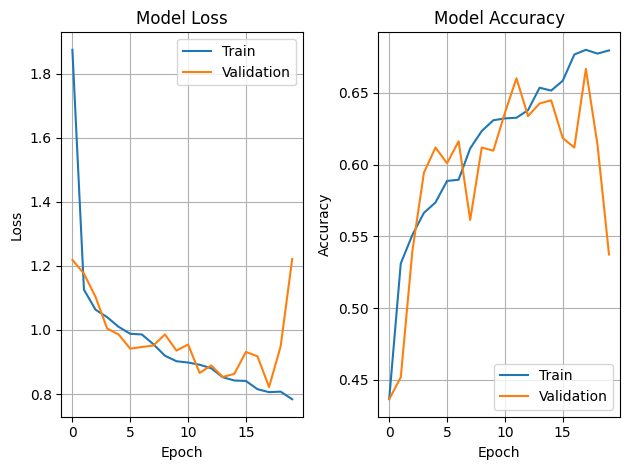

In [7]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import random
from PIL import Image
# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])  
plt.plot(history.history['val_accuracy']) 
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)

plt.tight_layout()
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\loss_accuracy_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight') 
plt.show()

In [8]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Test",
    seed= 123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle = False
)

Found 457 files belonging to 4 classes.


In [9]:
model.evaluate(test_ds)

15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.7560 - loss: 0.6825


[0.8180225491523743, 0.6630197167396545]

In [10]:
ts_length = len(test_ds)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_ds, steps= test_steps, verbose= 1)
valid_score = model.evaluate(val_ds, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_ds)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6250 - loss: 0.8760
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6875 - loss: 0.9121
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.7560 - loss: 0.6825
Train Loss:  0.8760218620300293
Train Accuracy:  0.625
--------------------
Validation Loss:  0.9120805263519287
Validation Accuracy:  0.6875
--------------------
Test Loss:  0.8180225491523743
Test Accuracy:  0.6630197167396545


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, class_names):
    """
    Plots the confusion matrix and prints the classification report.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        class_names (list): List of class names.
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Print classification report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))


    # Normalize to percentages per row (true label)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (in %)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Confusion Matrix.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight') 
    plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step

Classification Report:

                  precision    recall  f1-score   support

Ascochyta blight       0.47      0.85      0.60       111
     Lentil Rust       0.95      0.78      0.86        95
          Normal       0.74      0.55      0.63       143
  Powdery Mildew       0.79      0.53      0.63       108

        accuracy                           0.66       457
       macro avg       0.74      0.67      0.68       457
    weighted avg       0.73      0.66      0.67       457



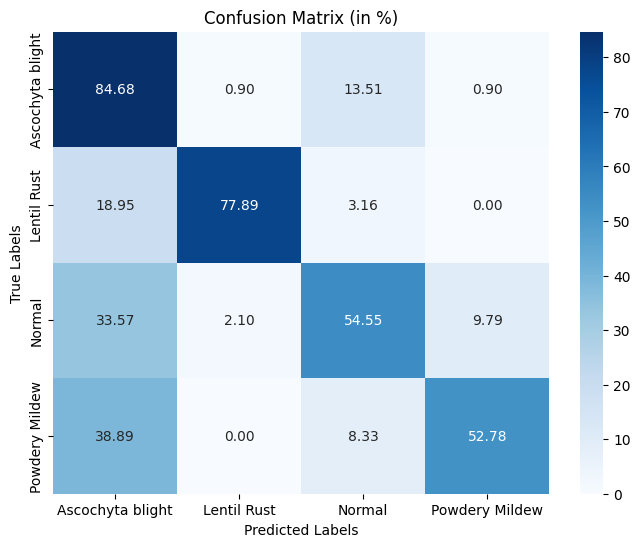

In [12]:
# 1. Predict
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. True labels
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# 3. Class names
class_names =  ['Ascochyta blight', 'Lentil Rust', 'Normal', 'Powdery Mildew']

# 4. Evaluate 
evaluate_model(y_true, y_pred, class_names)

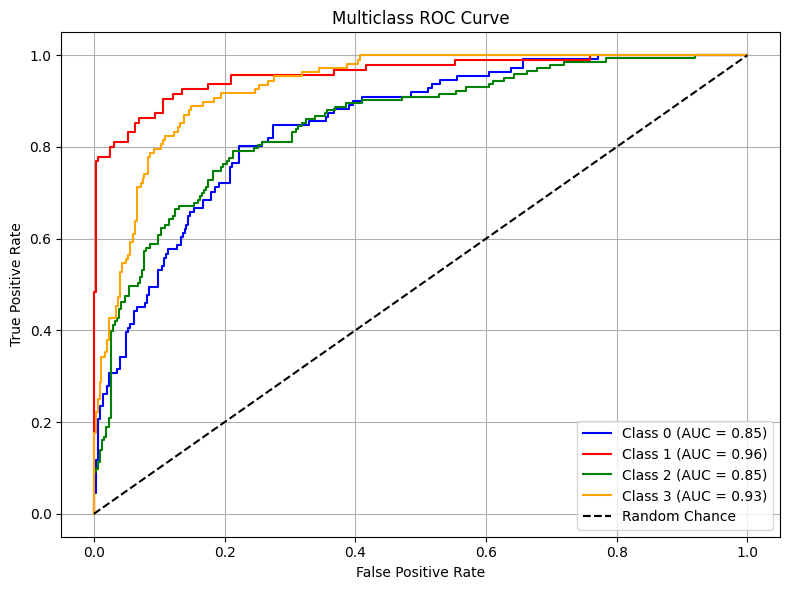

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = y_pred_probs.shape[1]

# One-hot encode the true labels
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# === Compute ROC and AUC for each class ===
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# === Plot all ROC curves ===
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\ROC_Curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [14]:
import tensorflow as tf
from tensorflow.keras.applications import NASNetLarge
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras import layers, models, applications, optimizers

In [15]:
# Paths to data
train_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Train'
val_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Validation'
img_size = 224  # Standard input size for DenseNet201
batch_size = 32
seed = 123
# =====================================================================
#                     Simplified Dataset Loading
# =====================================================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True,
    label_mode='categorical' 
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True,
    label_mode='categorical'
)


# Optimize data loading
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 4540 files belonging to 4 classes.
Found 456 files belonging to 4 classes.


In [16]:
from keras import backend as K
from keras.preprocessing import image
from keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Activation, Dropout, Flatten, Dense
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D

In [17]:
resnet = tf.keras.applications.NASNetLarge(
    weights='imagenet',
    include_top=False,
    input_shape= (img_size,img_size,3))

for layer in resnet.layers:
    layer.trainable = False

resnet.trainable = True
def build_model():
    model = Sequential()
    model.add(resnet)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(4096, activation='relu')) #sigmoid
    model.add(Dropout(0.2))
    model.add(Dense(4, activation='softmax'))
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizers.Adam(1e-4), #1e-4
        metrics=['accuracy'])
     
    return model

model = build_model()

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ nasnet_large (Functional)            │ (None, 7, 7, 4032)          │      84,916,818 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 4032)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4096)                │      16,519,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │          16,388 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,452,374 (387.01 MB)

 Trainable params: 16,535,556 (63.08 MB)

 Non-trainable params: 84,916,818 (323.93 MB)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=5,              # Wait for 3 epochs with no improvement
    restore_best_weights=True  # Restore model weights from the best epoch
)
checkpoint = ModelCheckpoint(
    'best_model.keras',          # File to save
    monitor='val_accuracy',    # Metric to watch
    save_best_only=True,       # Only save best model
    mode='max',                # 'max' for accuracy, 'min' for loss
    verbose=1                  # Print when saved
)

In [20]:
# Initial training with frozen base
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping,checkpoint],
    shuffle = False
)  

Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3556 - loss: 1.7178
Epoch 1: val_accuracy improved from -inf to 0.50877, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 471s 3s/step - accuracy: 0.3561 - loss: 1.7158 - val_accuracy: 0.5088 - val_loss: 1.1344
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4794 - loss: 1.2598
Epoch 2: val_accuracy improved from 0.50877 to 0.59868, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 446s 3s/step - accuracy: 0.4795 - loss: 1.2594 - val_accuracy: 0.5987 - val_loss: 1.0372
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5151 - loss: 1.1512
Epoch 3: val_accuracy did not improve from 0.59868
142/142 ━━━━━━━━━━━━━━━━━━━━ 442s 3s/step - accuracy: 0.5153 - loss: 1.1509 - val_accuracy: 0.5636 - val_loss: 1.0802
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5592 - loss: 1.0724
Epoch 4: val_accuracy did not improve from 0.59868
142/142 ━━━━━━━━━━━━━━━━━━━━ 

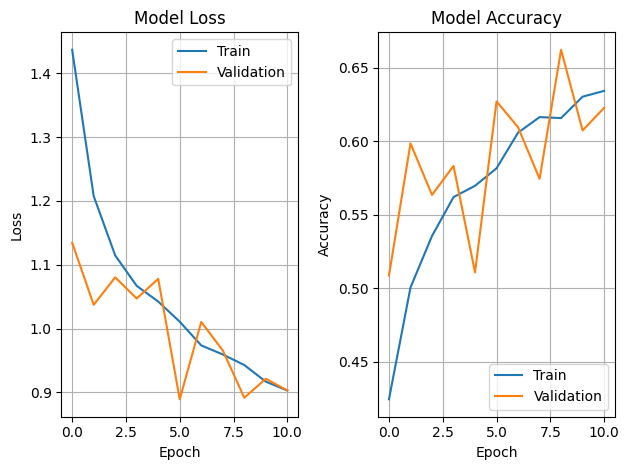

In [21]:
# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])  
plt.plot(history.history['val_accuracy']) 
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)

plt.tight_layout()
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\loss_accuracy_curve_1.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight') 
plt.show()

In [22]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Test",
    seed= 123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle = False,
    label_mode='categorical'
)

Found 457 files belonging to 4 classes.


In [23]:
model.evaluate(test_ds)

15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.5252 - loss: 1.0844


[0.8808170557022095, 0.6564551591873169]

In [24]:
ts_length = len(test_ds)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_ds, steps= test_steps, verbose= 1)
valid_score = model.evaluate(val_ds, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_ds)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5625 - loss: 0.9492
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6875 - loss: 0.7811
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.5252 - loss: 1.0844
Train Loss:  0.9491554498672485
Train Accuracy:  0.5625
--------------------
Validation Loss:  0.7810915112495422
Validation Accuracy:  0.6875
--------------------
Test Loss:  0.8808170557022095
Test Accuracy:  0.6564551591873169


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, class_names):
    """
    Plots the confusion matrix and prints the classification report.

    Args:
        y_true (array-like): True labels (1D array of class indices).
        y_pred (array-like): Predicted labels (1D array of class indices).
        class_names (list): List of class names.
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Print classification report
    print("\nClassification Report:\n")   
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Normalize to percentages per row (true label)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (in %)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Confusion Matrix_1.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight') 
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

Classification Report:

                  precision    recall  f1-score   support

Ascochyta blight       0.61      0.32      0.42       111
     Lentil Rust       0.81      0.84      0.82        95
          Normal       0.66      0.61      0.64       143
  Powdery Mildew       0.58      0.90      0.70       108

        accuracy                           0.66       457
       macro avg       0.66      0.67      0.65       457
    weighted avg       0.66

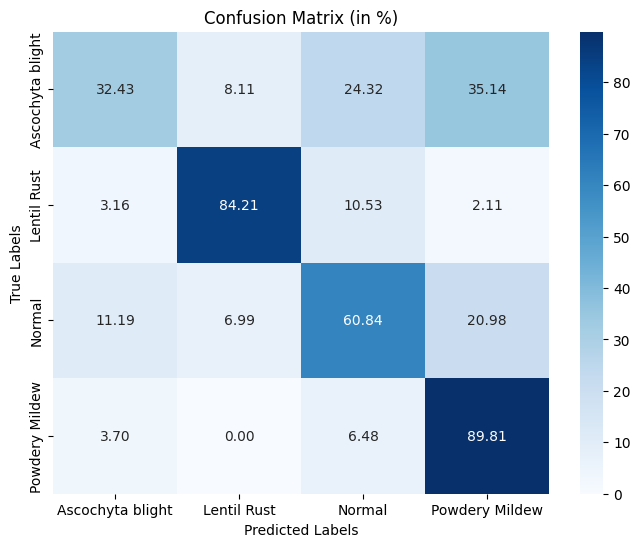

In [26]:
# --- Get true labels and predictions from model on test set ---
y_true = []
y_pred_proba = []

for images, labels in test_ds:
    y_true.append(labels.numpy())             # Assuming labels are one-hot or class indices
    preds = model.predict(images)             # preds: [batch_size, num_classes]
    y_pred_proba.append(preds)

# Stack into arrays
y_true = np.vstack(y_true)
y_pred_proba = np.vstack(y_pred_proba)

# Convert one-hot encoded y_true to class indices (if needed)
if y_true.shape[1] > 1:
    y_true = np.argmax(y_true, axis=1)
else:
    y_true = y_true.flatten()

# Convert predicted probabilities to class indices
y_pred = np.argmax(y_pred_proba, axis=1)

# Class names
class_names = ['Ascochyta blight', 'Lentil Rust', 'Normal', 'Powdery Mildew']

# Evaluate the model
evaluate_model(y_true, y_pred, class_names)


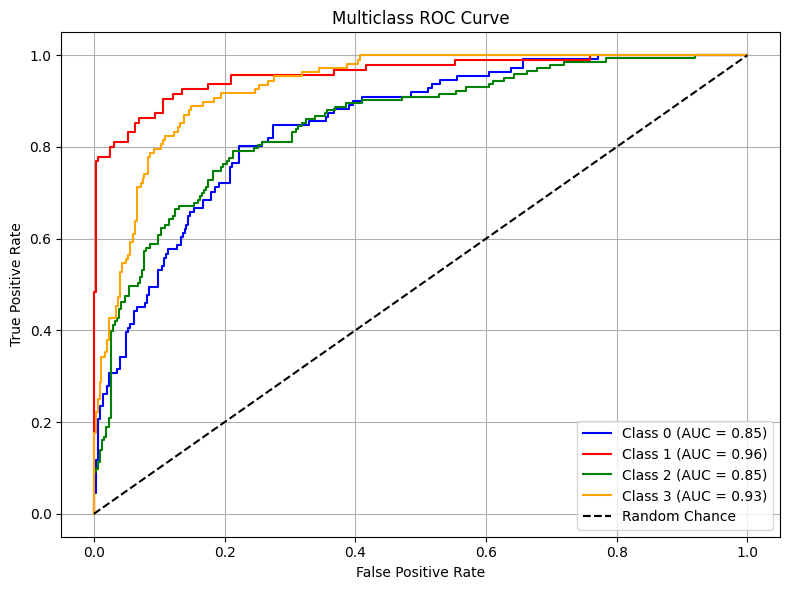

In [27]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = y_pred_probs.shape[1]

# One-hot encode the true labels
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# === Compute ROC and AUC for each class ===
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# === Plot all ROC curves ===
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\ROC_Curve_1.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()